In [1]:
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
dir_path = "/vision/asomaya1/active-rir/runs_eval/fs_rir"

with open(os.path.join(dir_path, "seen_eval_798datapoints_metrics.pkl"), "rb") as f:
    metric_data = pickle.load(f)

with open(os.path.join(dir_path, "seen_eval_798datapoints_sceneNames.pkl"), "rb") as f:
    scene_names = pickle.load(f)

with open("/vision/asomaya1/active-rir/data/metadata/scene_sizes.json", "rb") as f:
    scene_to_room_size = json.load(f)


In [3]:
# Calculate test set statistics
test_set_statistics = {}
for metric_name, metric_values in metric_data.items():
    mean = np.mean(metric_values)
    median = np.median(metric_values)
    std = np.std(metric_values)
    test_set_statistics[metric_name] = {
        'mean': mean,
        'median': median,
        'std': std
    }

scene_statistics = {}
# Iterate through unique scene names in your_scene_names
for scene_name in set(scene_names):
    scene_indices = [i for i, name in enumerate(scene_names) if name == scene_name]
    room_size = scene_to_room_size.get(scene_name, None)  # Get the room size, if available
    num_episodes = len(scene_indices)
    
    if room_size is not None:
        scene_metric_values = {}
        
        # Calculate statistics for each metric
        for metric_name, metric_values in metric_data.items():
            scene_metric_values[metric_name] = {
                'mean': np.mean([metric_values[i] for i in scene_indices]),
                'median': np.median([metric_values[i] for i in scene_indices]),
                'std': np.std([metric_values[i] for i in scene_indices]),
            }
        
        # Store the scene statistics in the scene_statistics dictionary
        scene_statistics[scene_name] = {
            'num_episodes': num_episodes,
            'room_size': room_size,
            'metrics': scene_metric_values
        }

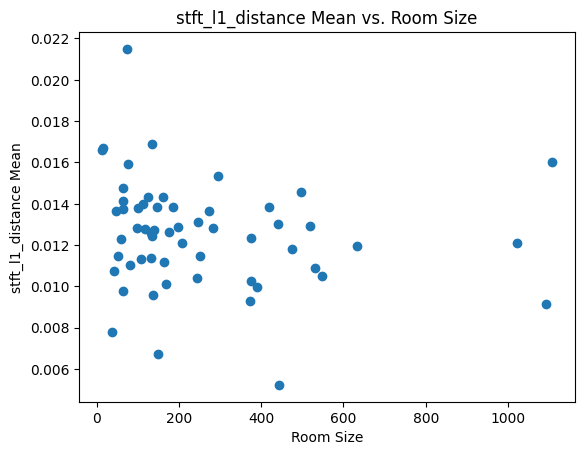

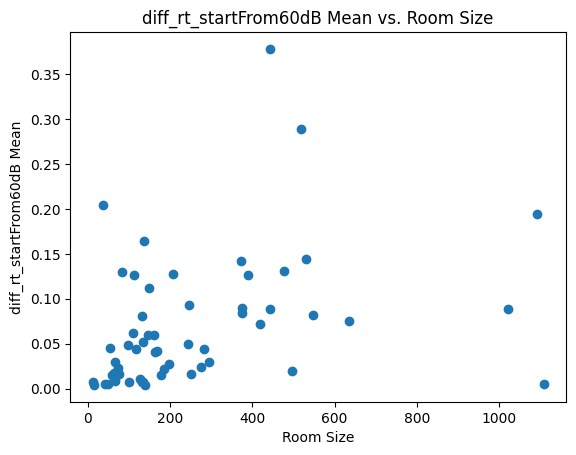

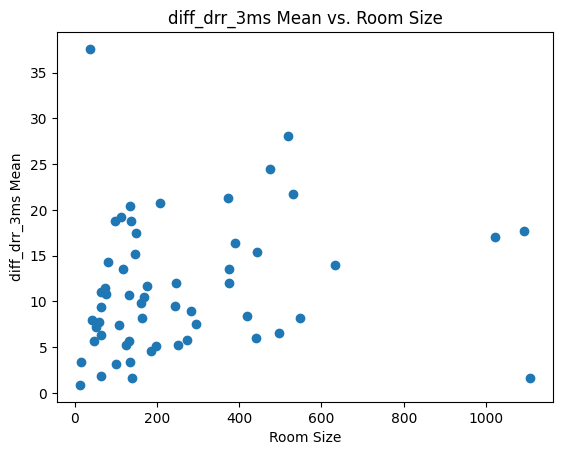

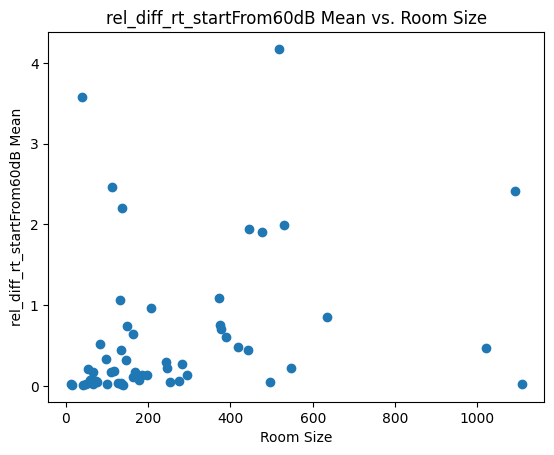

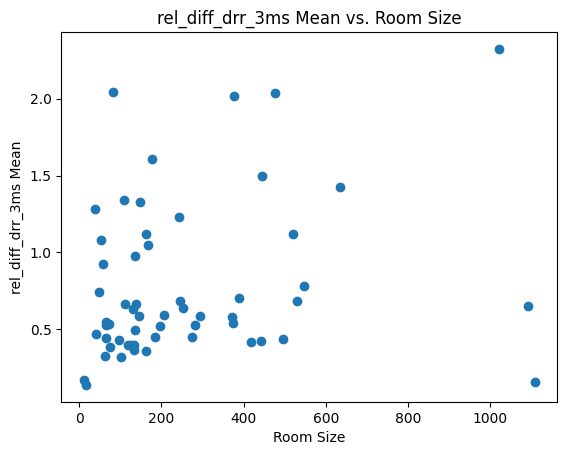

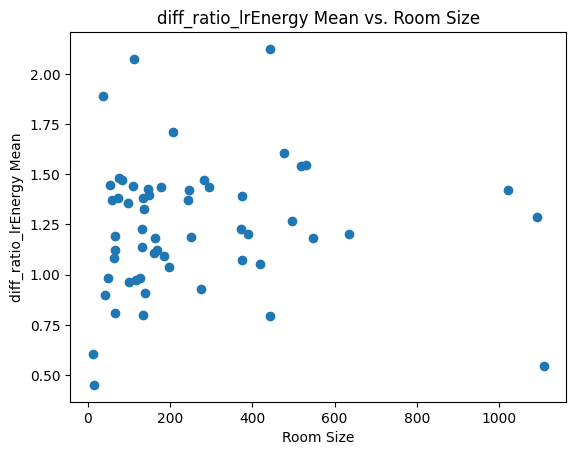

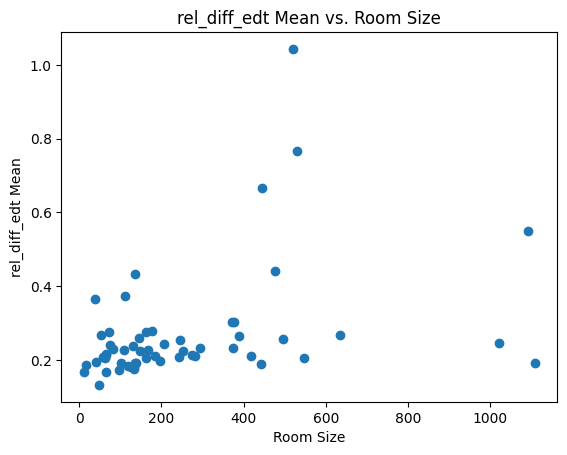

In [4]:
# Extract metric means and room sizes from scene statistics
metric_means = {metric_name: [] for metric_name in metric_data.keys()}
room_sizes = []

for scene_name, scene_data in scene_statistics.items():
    room_size = scene_data['room_size']
    room_sizes.append(room_size)
    
    for metric_name, metric_stats in scene_data['metrics'].items():
        metric_mean = metric_stats['mean']
        metric_means[metric_name].append(metric_mean)

# Create a bar plot for each metric
for metric_name, mean_values in metric_means.items():
    plt.figure()
    plt.scatter(room_sizes, mean_values)
    plt.xlabel('Room Size')
    plt.ylabel(metric_name + ' Mean')
    plt.title(metric_name + ' Mean vs. Room Size')
    plt.show()

In [5]:
scenes_to_eval = ['GdvgFV5R1Z5']
#scenes_to_eval = list(set(scene_names))
drrs = []
for scene in scenes_to_eval:
    print(scene + " ({} episodes):".format(scene_statistics[scene]['num_episodes']))
    for metric in scene_statistics[scene]['metrics']:
        print(metric+":", scene_statistics[scene]['metrics'][metric]['mean'])
    print()

GdvgFV5R1Z5 (660 episodes):
stft_l1_distance: 0.01668343918087582
diff_rt_startFrom60dB: 0.0042097537878787875
diff_drr_3ms: 3.338247061220147
rel_diff_rt_startFrom60dB: 0.014513351406885651
rel_diff_drr_3ms: 0.13823217287195746
diff_ratio_lrEnergy: 0.45073788411050864
rel_diff_edt: 0.18472106414868494



In [6]:
#overall test statistics
for key in test_set_statistics.keys():
    print(key)
    print(test_set_statistics[key])

stft_l1_distance
{'mean': 0.012436565287593425, 'median': 0.011718436609953642, 'std': 0.00757397434070422}
diff_rt_startFrom60dB
{'mean': 0.06578424165883459, 'median': 0.004906249999999987, 'std': 0.2154214020837017}
diff_drr_3ms
{'mean': 11.351105568893452, 'median': 1.0994621543834953, 'std': 25.664603160778327}
rel_diff_rt_startFrom60dB
{'mean': 0.5935356483824942, 'median': 0.01674965390878399, 'std': 4.874424965073213}
rel_diff_drr_3ms
{'mean': 0.7788064347791867, 'median': 0.24786723741848976, 'std': 10.461415756866522}
diff_ratio_lrEnergy
{'mean': 1.239657975357943, 'median': 0.7208931230674767, 'std': 1.5001962114390879}
rel_diff_edt
{'mean': 0.26488460318642804, 'median': 0.16570424004064646, 'std': 1.9852923558329347}
